<a href="https://colab.research.google.com/github/deartoms/python/blob/main/Chapter03_%ED%8F%89%EA%B0%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

# 드라이브에 저장된 폰트 등록
import matplotlib as mpl
import matplotlib.pyplot as plt # 그래프를 그리는 모듈
import matplotlib.font_manager as fm # 폰트를 관리하는 모듈

# 드라이브 내 폰트 경로
font_path = '/content/drive/MyDrive/kwu/bigdata/dataPreProcessing/NanumGothic.ttf'

fm.fontManager.addfont(font_path)
mpl.rc('font', family='NanumGothic') # matplotlib 기본 폰트로 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['font.sans-serif'] = ['NanumGothic', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False # 마이너스(-) 기호가 깨지지 않도록 유니코드 마이너스 비활성화

print("현재 폰트: ", plt.rcParams['font.family']) # 현재 적용된 폰트 이름 출력

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
현재 폰트:  ['NanumGothic']


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, Binarizer, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, # 분류 모델 평가 지표
    precision_recall_curve, roc_curve, roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

In [ ]:
diabetes_data = pd.read_csv('/content/drive/MyDrive/kwu/ML/data/diabetes.csv')
print('레이블 분포:')
print(diabetes_data['Outcome'].value_counts())
print(f"당뇨 비율 (원본 데이터셋):{diabetes_data['Outcome'].mean()*100:.1f}%")
display(diabetes_data.head(3))

레이블 분포:
Outcome
0    500
1    268
Name: count, dtype: int64
당뇨 비율 (원본 데이터셋):34.9%


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


In [ ]:
print('데이터 정보:')
diabetes_data.info()

데이터 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
# 전처리 없이 기본 학습/평가
# 피처(X): 마지막 컬럼(Outcome) 제외한 전체
# 레이블(y): 마지막 컬럼(Outcome)
X = diabetes_data.iloc[:, :-1] # 'Outcome' 컬럼을 제외한 모든 피처(독립 변수) 선택
y = diabetes_data.iloc[:, -1] # 'Outcome' 컬럼만 레이블또는타겟(종속 변수)로 선택

# train 데이터와 test 데이터를 8:2 비율로 분할, y의 클래스 비율을 유지
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=156, stratify=y)

lr_clf = LogisticRegression(solver='liblinear') # 로지스틱 회귀 모델 객체 생성
lr_clf.fit(X_train, y_train) # train 데이터로 모델 학습

pred = lr_clf.predict(X_test) # test 데이터에 대한 예측 레이블 생성
pred_proba = lr_clf.predict_proba(X_test)[:, 1] # 예측 확률 [음성,양성] -> 양성(당뇨, 1) 클래스 예측 확률 추출
pred_proba

array([0.04160518, 0.20912837, 0.16482046, 0.51656925, 0.08149191,
       0.69376403, 0.71327173, 0.18558971, 0.18703208, 0.20057413,
       0.62803286, 0.48349546, 0.07639987, 0.34868451, 0.26331384,
       0.14246821, 0.71563568, 0.34133315, 0.03127028, 0.71637019,
       0.35090426, 0.3047434 , 0.07254422, 0.33017374, 0.3006481 ,
       0.1474334 , 0.84947379, 0.65846711, 0.25135397, 0.79328356,
       0.20199844, 0.22273526, 0.17965591, 0.2498647 , 0.17605363,
       0.57951255, 0.28689364, 0.54658369, 0.74887899, 0.6323581 ,
       0.48465258, 0.29961761, 0.59477436, 0.21643951, 0.35035968,
       0.05709475, 0.71563467, 0.13282124, 0.50014795, 0.31771476,
       0.32256529, 0.81031197, 0.83237246, 0.11303412, 0.18887807,
       0.37452468, 0.10650238, 0.38928495, 0.34623632, 0.44244719,
       0.22793794, 0.72712818, 0.31276835, 0.6078356 , 0.27536949,
       0.15379414, 0.22640726, 0.7107828 , 0.19017568, 0.72366567,
       0.12294106, 0.33725937, 0.14888921, 0.45163981, 0.64891

In [ ]:
print('전처리 전 로지스틱 회귀 성능')
confusion = confusion_matrix(y_test, pred) # 오차 행렬 계산
accuracy  = accuracy_score(y_test, pred)   # 정확도 계산
precision = precision_score(y_test, pred)  # 정밀도 계산
recall    = recall_score(y_test, pred)     # 재현율 계산
f1        = f1_score(y_test, pred)         # F1 스코어 계산
roc_auc   = roc_auc_score(y_test, pred_proba) # AUC 계산

print('오차 행렬')
print(confusion)
TN, FP, FN, TP = confusion[0,0], confusion[0,1], confusion[1,0], confusion[1,1]
print(f'\nTN(진음성): {TN} FP(위양성): {FP}')
print(f'FN(위음성): {FN} TP(진양성): {TP}')

print('\n정확도:{0:.4f}, 정밀도:{1:.4f}, 재현율:{2:.4f}, F1:{3:.4f}, AUC:{4:.4f}'.format(
            accuracy, precision, recall, f1, roc_auc))
# 정밀도precision : 양성 예측 중 실제 양성 비율
# 재현율recall : 실제 양성 중 양성으로 예측한 비율

전처리 전 로지스틱 회귀 성능
오차 행렬
[[87 13]
 [22 32]]

TN(진음성): 87 FP(위양성): 13
FN(위음성): 22 TP(진양성): 32

정확도:0.7727, 정밀도:0.7111, 재현율:0.5926, F1:0.6465, AUC:0.8083


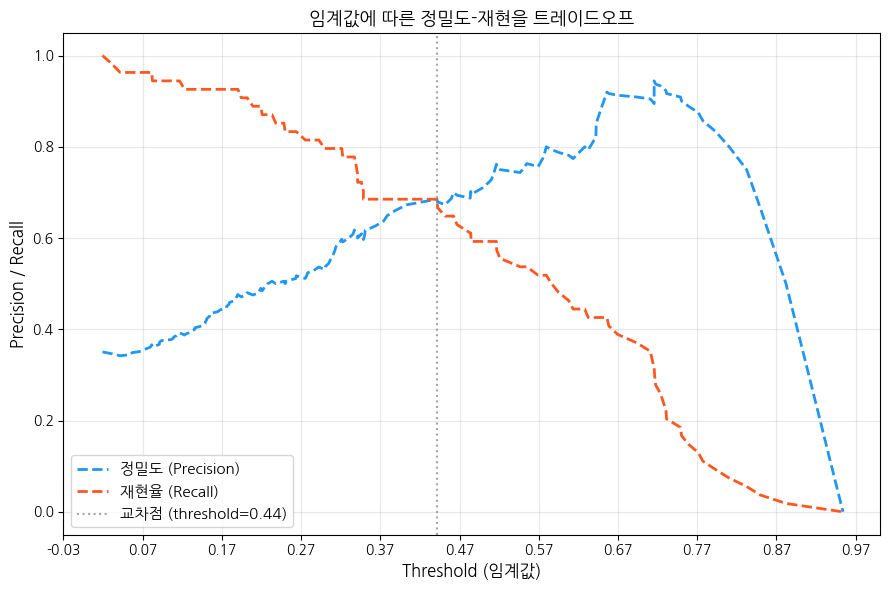

In [ ]:
# 정밀도-재현율 곡선으로 최적 임계값 탐색
precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba)

plt.figure(figsize=(9, 6))
n = thresholds.shape[0]
plt.plot(thresholds, precisions[:n], linestyle='--', label='정밀도 (Precision)',
         color='#2196F3', linewidth=2)# 정밀도 곡선 그리기
plt.plot(thresholds, recalls[:n], linestyle='--', label='재현율 (Recall)',
         color='#FF5722', linewidth=2)# 재현율 곡선 그리기
cross_idx = np.argmin(np.abs(precisions[:n] - recalls[:n])) # 정밀도와 재현율 차이의 절댓값이 가장 작은 인덱스 찾기
plt.axvline(thresholds[cross_idx], color='gray', linestyle=':', alpha=0.7,
            label=f'교차점 (threshold={thresholds[cross_idx]:.2f})')
start, end = plt.xlim() # x축 범위 가져오기
plt.xticks(np.round(np.arange(start, end, 0.1), 2))
plt.xlabel('Threshold (임계값)', fontsize=12)
plt.ylabel('Precision / Recall', fontsize=12)
plt.title('임계값에 따른 정밀도-재현을 트레이드오프', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# 임계값 세밀하게 탐색
thresholds = [0.30, 0.33, 0.36, 0.39, 0.42, 0.45, 0.48, 0.50]
pred_proba = lr_clf.predict_proba(X_test)[:, 1]

print('임계값별 성능 비교')
for threshold in thresholds: # Binarizer는 임계값(Threshold)을 기준으로 0 또는 1의 이진 값으로 변환
  binarizer = Binarizer(threshold=threshold).fit(pred_proba.reshape(-1, 1))
  pred = binarizer.transform(pred_proba.reshape(-1, 1)) # 임계값 기준으로 이진 예측 레이블 생성
  print(f'\n임계값: {threshold}')

  # 생성된 예측 레이블과 실제 레이블로 모델 성능 평가 (AUC 포함)
  confusion = confusion_matrix(y_test, pred) # 오차 행렬 계산
  accuracy  = accuracy_score(y_test, pred)   # 정확도 계산
  precision = precision_score(y_test, pred)  # 정밀도 계산
  recall    = recall_score(y_test, pred)     # 재현율 계산
  f1        = f1_score(y_test, pred)         # F1 스코어 계산
  roc_auc   = roc_auc_score(y_test, pred_proba) # AUC 계산

  print('오차 행렬')
  print(confusion)
  TN, FP, FN, TP = confusion[0,0], confusion[0,1], confusion[1,0], confusion[1,1]
  print(f'\nTN(진음성): {TN} FP(위양성): {FP}')
  print(f'FN(위음성): {FN} TP(진양성): {TP}')

  print('\n정확도:{0:.4f}, 정밀도:{1:.4f}, 재현율:{2:.4f}, F1:{3:.4f}, AUC:{4:.4f}'.format(
            accuracy, precision, recall, f1, roc_auc))
  # 정밀도precision : 양성 예측 중 실제 양성 비율
  # 재현율recall : 실제 양성 중 양성으로 예측한 비율

임계값별 성능 비교

임계값: 0.3
오차 행렬
[[63 37]
 [11 43]]

TN(진음성): 63 FP(위양성): 37
FN(위음성): 11 TP(진양성): 43

정확도:0.6883, 정밀도:0.5375, 재현율:0.7963, F1:0.6418, AUC:0.8083

임계값: 0.33
오차 행렬
[[72 28]
 [12 42]]

TN(진음성): 72 FP(위양성): 28
FN(위음성): 12 TP(진양성): 42

정확도:0.7403, 정밀도:0.6000, 재현율:0.7778, F1:0.6774, AUC:0.8083

임계값: 0.36
오차 행렬
[[78 22]
 [17 37]]

TN(진음성): 78 FP(위양성): 22
FN(위음성): 17 TP(진양성): 37

정확도:0.7468, 정밀도:0.6271, 재현율:0.6852, F1:0.6549, AUC:0.8083

임계값: 0.39
오차 행렬
[[82 18]
 [17 37]]

TN(진음성): 82 FP(위양성): 18
FN(위음성): 17 TP(진양성): 37

정확도:0.7727, 정밀도:0.6727, 재현율:0.6852, F1:0.6789, AUC:0.8083

임계값: 0.42
오차 행렬
[[83 17]
 [17 37]]

TN(진음성): 83 FP(위양성): 17
FN(위음성): 17 TP(진양성): 37

정확도:0.7792, 정밀도:0.6852, 재현율:0.6852, F1:0.6852, AUC:0.8083

임계값: 0.45
오차 행렬
[[83 17]
 [19 35]]

TN(진음성): 83 FP(위양성): 17
FN(위음성): 19 TP(진양성): 35

정확도:0.7662, 정밀도:0.6731, 재현율:0.6481, F1:0.6604, AUC:0.8083

임계값: 0.48
오차 행렬
[[85 15]
 [21 33]]

TN(진음성): 85 FP(위양성): 15
FN(위음성): 21 TP(진양성): 33

정확도:0.7662, 정밀도:0.6875, 재현율:0.6111, F1:0

In [ ]:
# 최적 임계값: 0.42, 정밀도:0.6852, 재현율:0.6852, F1:0.6852, AUC:0.8083
# 기본 임계값(0.5)보다 낮음 -> 재현율 약간 향상
# 정밀도와 재현율의 균형점

binarizer_final = Binarizer(threshold=0.42)
pred_final = binarizer_final.fit_transform(pred_proba.reshape(-1, 1)) # 최종적으로 0 또는 1로 이진화된 예측
print('최적 임계값 적용 최종 평가')

confusion = confusion_matrix(y_test, pred) # 오차 행렬 계산
accuracy  = accuracy_score(y_test, pred)   # 정확도 계산
precision = precision_score(y_test, pred)  # 정밀도 계산
recall    = recall_score(y_test, pred)     # 재현율 계산
f1        = f1_score(y_test, pred)         # F1 스코어 계산
roc_auc   = roc_auc_score(y_test, pred_proba) # AUC 계산

print('오차 행렬')
print(confusion)
TN, FP, FN, TP = confusion[0,0], confusion[0,1], confusion[1,0], confusion[1,1]
print(f'\nTN(진음성): {TN} FP(위양성): {FP}')
print(f'FN(위음성): {FN} TP(진양성): {TP}')

print('\n정확도:{0:.4f}, 정밀도:{1:.4f}, 재현율:{2:.4f}, F1:{3:.4f}, AUC:{4:.4f}'.format(
            accuracy, precision, recall, f1, roc_auc))


최적 임계값 적용 최종 평가
오차 행렬
[[87 13]
 [22 32]]

TN(진음성): 87 FP(위양성): 13
FN(위음성): 22 TP(진양성): 32

정확도:0.7727, 정밀도:0.7111, 재현율:0.5926, F1:0.6465, AUC:0.8083


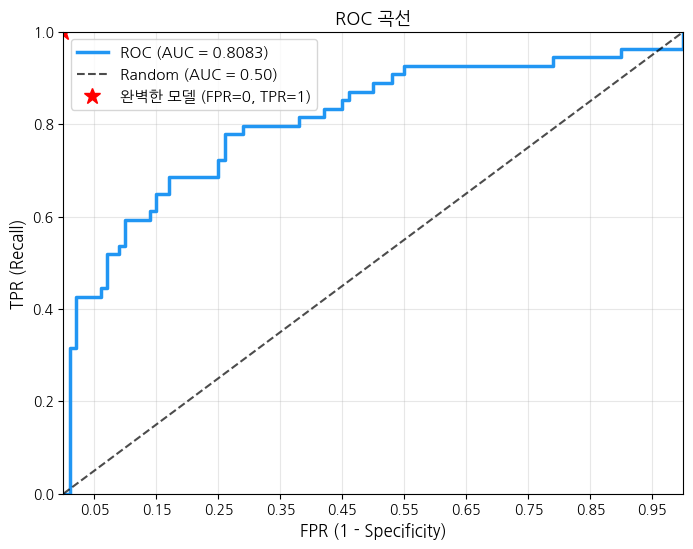

In [ ]:
# 최종 ROC 곡선 및 AUC 확인
fprs, tprs, _ = roc_curve(y_test, pred_proba) # FPR, TPR 계산, _는 임계값 사용하지 않기에
auc_val = roc_auc_score(y_test, pred_proba) # ROC AUC 값 계산

plt.figure(figsize=(8, 6))
plt.plot(fprs, tprs, label=f'ROC (AUC = {auc_val:.4f})', color='#2196F3', linewidth=2.5)
plt.plot([0,1], [0,1], 'k--', label='Random (AUC = 0.50)', linewidth=1.5, alpha=0.7) # (0,0)에서 (1,1)까지
plt.plot(0, 1, 'r*', markersize=12, label='완벽한 모델 (FPR=0, TPR=1)') # 완벽한 모델 위치 표시: FPR=0, TPR=1인 지점

start, end = plt.xlim()
plt.xticks(np.round(np.arange(start, end, 0.1), 2))
plt.xlim(0, 1) # x,y 축 범위를 0에서 1로 고정
plt.ylim(0, 1)
plt.xlabel('FPR (1 - Specificity)', fontsize=12)
plt.ylabel('TPR (Recall)', fontsize=12)
plt.title('ROC 곡선', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout
plt.show()

In [ ]:
# 의학 데이터에서 혈당, 혈압 등이 0이면 측정 불가 = 결측치
print('기술통계:')
display(diabetes_data.describe())

기술통계:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
# 0값을 가진 피처별 비율 확인
zero_features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
total_count = len(diabetes_data)

print('0값이 있는 피처별 건수와 비율:')
for feat in zero_features:
  zero_count = (diabetes_data[feat] == 0).sum()
  pct = 100 * zero_count / total_count # 0값의 비율 계산
  bar = '█' * int(pct / 2)
  print(f' {feat:25}: {zero_count:3d}건 ({pct:5.1f}%) {bar}')

0값이 있는 피처별 건수와 비율:
 Glucose                  :   5건 (  0.7%) 
 BloodPressure            :  35건 (  4.6%) ██
 SkinThickness            : 227건 ( 29.6%) ██████████████
 Insulin                  : 374건 ( 48.7%) ████████████████████████
 BMI                      :  11건 (  1.4%) 


In [ ]:
# 0값 -> 평균값 대체
mean_zero = diabetes_data[zero_features].mean() # 각 피처의 평균 계산
diabetes_data[zero_features] = diabetes_data[zero_features].replace(0, mean_zero)
zero_after = {f: (diabetes_data[f] == 0).sum() for f in zero_features}
print('대체 후 0값 개수:', zero_after)

대체 후 0값 개수: {'Glucose': np.int64(0), 'BloodPressure': np.int64(0), 'SkinThickness': np.int64(0), 'Insulin': np.int64(0), 'BMI': np.int64(0)}


In [ ]:
# 전처리
# 피처(X): 마지막 컬럼(Outcome) 제외한 전체
# 레이블(y): 마지막 컬럼(Outcome)
X = diabetes_data.iloc[:, :-1] # 'Outcome' 컬럼을 제외한 모든 피처(독립 변수) 선택
y = diabetes_data.iloc[:, -1] # 'Outcome' 컬럼만 레이블또는타겟(종속 변수)로 선택

# 표준화: 모든 피처를 평균=0, 표준편차=1로 변환
# 로지스틱 회귀는 스케일에 민감하므로 표준화 후 성능 향상
# train 데이터와 test 데이터를 8:2 비율로 분할, y의 클래스 비율을 유지
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=156, stratify=y)

lr_clf = LogisticRegression(solver='liblinear') # 로지스틱 회귀 모델 객체 생성
lr_clf.fit(X_train, y_train) # train 데이터로 모델 학습

pred = lr_clf.predict(X_test) # test 데이터에 대한 예측 레이블 생성
pred_proba = lr_clf.predict_proba(X_test)[:, 1] # 예측 확률 [음성,양성] -> 양성(당뇨, 1) 클래스 예측 확률 추출
pred_proba

array([0.06922473, 0.22807679, 0.15847851, 0.54586167, 0.32845245,
       0.73899706, 0.71162044, 0.19522431, 0.17487966, 0.23049236,
       0.64164378, 0.52958406, 0.07246772, 0.31821951, 0.28196442,
       0.16346469, 0.72010163, 0.13391094, 0.54693356, 0.71228891,
       0.34367032, 0.30833985, 0.06742429, 0.32776107, 0.29098233,
       0.11420716, 0.8614462 , 0.67668042, 0.23683545, 0.80807173,
       0.19708222, 0.22744898, 0.17685522, 0.30102615, 0.18805633,
       0.58155561, 0.32887448, 0.26195001, 0.74191182, 0.63534155,
       0.49152839, 0.26722324, 0.56542831, 0.22802389, 0.32823855,
       0.05276229, 0.44992296, 0.13446339, 0.48946392, 0.33709762,
       0.31476958, 0.81694506, 0.84573471, 0.12247921, 0.17245404,
       0.38086088, 0.09772932, 0.38841813, 0.36365803, 0.4430839 ,
       0.2523173 , 0.74610644, 0.29119701, 0.6368931 , 0.28503615,
       0.15969403, 0.20329137, 0.7205348 , 0.20187699, 0.73368196,
       0.12966179, 0.34583285, 0.15117611, 0.46972472, 0.59607

### F1-score 평가지표 사용 이유

위기 상황을 얼마나 잘 맞추는지 머신러닝 분류(Claasification) 문제를 풀때
* 주차장 만차
* 자전거 부족
* 지하철 매우혼잡